# Record linkage and semantic joins: a short primer

**Choose the relation first, then test whether interpreting text improves the join.** Splink combines evidence for entity identity. LOTUS lets a program express a relation in language and evaluate it over records. Both need evaluation against the intended relation.

This primer keeps one scoring example, the saved person-linkage comparison and two small text examples. The [NSO results notebook](nso-semantic-workflows.ipynb) contains the application evidence and next steps. The reported results describe the saved 6 October 2026 runs. Default execution uses saved model responses; it makes no paid calls.

In [1]:
from pathlib import Path
from importlib.metadata import version
from time import perf_counter
from datetime import datetime, timezone
import hashlib
import json
import logging
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
from splink import DuckDBAPI, Linker, SettingsCreator
import splink.comparison_library as cl
# Use the installed pricing metadata; replay should not fetch a remote cost map.
os.environ["LITELLM_LOCAL_MODEL_COST_MAP"] = "True"
import lotus

# Support opening Jupyter either at the repo root or in LLM_basics.
HERE = Path.cwd()
SUPPORT = next((p for p in [HERE / "record-linkage-tutorial",
    HERE / "LLM_basics" / "record-linkage-tutorial"] if p.is_dir()), None)
if SUPPORT is None:
    raise FileNotFoundError("Open this notebook from LLM_basics or the repository root.")
sys.path.insert(0, str(SUPPORT.resolve()))
from tutorial_helpers import (AuditedLM, as_semantic_records, label_pairs, metrics,
    pair_grid, run_spec, save_snapshot, load_snapshot, select_threshold, preflight_cost)

RUN_LIVE = False
RUN_UNSTRUCTURED_LIVE = False
RUN_AGENTIC_LIVE = False
MODEL = "gpt-6-luna"
MAX_LIVE_PAIRS = 225
SNAPSHOT = SUPPORT / "results" / "lotus-febrl4-gpt-6-luna.json"
assert version("splink") == "5.0.0" and version("lotus-ai") == "1.2.4"
lotus.logger.setLevel(logging.ERROR)
display(pd.Series({p: version(p) for p in
    ["splink", "lotus-ai", "duckdb", "pandas", "litellm"]}, name="installed version"))
from handbook_examples import (format_percent, diagram, evidence_example, duplicated_evidence_example,
    reference_example, controlled_prose, repair_benefit_example, bridge_example, scale_example, recall_example)
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 100)

splink        5.0.0
lotus-ai      1.2.4
duckdb        1.5.6
pandas        2.3.3
litellm     1.104.0
Name: installed version, dtype: object

## 1. What relation are we joining on?

| Two inputs | Requested relation | What an accepted pair means |
|---|---|---|
| Two person records | Same person | An identity link |
| Affiliation text and registry entry | Text identifies organization | A normalized organization assignment |
| Report and reaction category | Report describes that reaction | A category assignment |
| Trial protocol and result article | Article reports outcomes from the trial | A link between different documents |

A semantic join evaluates a predicate over pairs. It can return no targets or several targets. Optical character recognition (OCR) recovers text from an image; extraction turns text into fields; candidate retrieval limits which pairs reach the predicate. Each can affect the final result.

For example, the native LOTUS API can express:

```python
reports.sem_join(categories, "The report {text:left} describes the reaction {reaction:right}.")
```

This expresses the requested relation. It does not guarantee correct decisions. [LOTUS paper](https://arxiv.org/abs/2407.11418).

## 2. How Splink combines identity evidence

Fellegi–Sunter linkage compares fields such as name, birth date and postcode. For comparison outcome $\gamma_k$, let $m_k=P(\gamma_k\mid M)$ among matches and $u_k=P(\gamma_k\mid U)$ among nonmatches. With conditionally independent comparison outcomes within each group,

$$\text{posterior odds}=\text{prior odds}\times\prod_k\frac{m_k}{u_k}.$$

Rare agreement can add more evidence than common agreement; contradiction can subtract evidence. The independence condition matters when fields repeat the same information. The calculated probability also depends on the assumed prior and fitted comparison probabilities.

The worked example below changes birth-date agreement to contradiction, leaving name and postcode evidence unchanged.

In [2]:
levels, example_scores = evidence_example(prior=0.0001)
display(levels.style.format({
    "m": format_percent, "u": format_percent,
    "likelihood ratio": lambda x: f"×{x:,.0f}" if x >= 1 else f"÷{1 / x:,.0f}",
    "weight (bits)": "{:+.1f}",
}))
display(example_scores.style.format({
    "prior probability": format_percent,
    "sum of weights (bits)": "{:.1f}",
    "posterior probability": format_percent,
}))

,m,u,likelihood ratio,weight (bits)
comparison outcome,,,,
Name agreement,85%,1%,×85,+6.4
Birth-date agreement,90%,0.2%,×450,+8.8
Birth-date contradiction,2%,90%,÷45,-5.5
Postcode agreement,60%,3%,×20,+4.3


,prior probability,sum of weights (bits),posterior probability
comparison pattern,,,
Three agreements,0.01%,19.5,98.7%
Birth date contradicts,0.01%,5.2,0.4%


The illustrative match probability drops from **98.7% to 0.4%**. Those are calculated values from a teaching model, not observed accuracy.

Splink can estimate comparison probabilities from labeled matches or use **expectation–maximization (EM)** with unlabeled pairs: estimate match probabilities from current parameters, update parameters using those fractional weights, and repeat. Label-free fitting still requires checks on assumptions, calibration and errors. [Splink documentation](https://moj-analytical-services.github.io/splink/).

## 3. The small person-linkage comparison

The fixed synthetic FEBRL4 slice contains **225 pairs and ten true links**. All methods receive the same six observed fields. Supervised Splink uses training labels and a validation-selected threshold. The EM procedure uses unlabeled training pairs and a fixed 50% threshold. LOTUS evaluates a same-person predicate using GPT-6 Luna.

The computation below retains the original supervised fit, verifies the saved EM artifacts and replays the saved semantic decisions. Test truth enters scoring after decisions. [Dataset and split](record-linkage-tutorial/data/README.md).

In [3]:
from IPython.utils.capture import capture_output
with capture_output():
    DATA = SUPPORT / "data"
    manifest = json.loads((DATA / "manifest.json").read_text())
    for filename, expected in manifest["output_sha256"].items():
        actual = hashlib.sha256((DATA / filename).read_bytes()).hexdigest()
        if actual != expected:
            raise ValueError(f"Prepared file changed: {filename}")

    records = pd.read_csv(DATA / "records.csv", dtype=str)
    truth = pd.read_csv(DATA / "record_truth.csv", dtype=str)
    assert "entity_id" not in records and "rec_id" not in records
    assert records.unique_id.is_unique and truth.unique_id.is_unique
    assert truth.groupby("entity_id").split.nunique().eq(1).all()
    counts = truth.groupby("split").agg(records=("unique_id", "size"),
        entities=("entity_id", "nunique"))
    display(counts)
    record_preview = records.drop(columns=["source", "unique_id"]).head(3).T
    record_preview.columns = ["Example record 1", "Example record 2", "Example record 3"]
    record_preview.index.name = "observed field"
    display(record_preview)

    FIELDS = ["given_name", "surname", "date_of_birth", "soc_sec_id",
              "street_number", "postcode"]
    observed = records[["source", "unique_id"] + FIELDS].copy()
    training = observed.merge(truth.loc[truth.split.eq("train"),
        ["unique_id", "entity_id"]], on="unique_id", validate="one_to_one")

    def load_slice(filename):
        ids = pd.read_csv(DATA / filename, dtype=str)
        selected = ids.merge(observed, on=["unique_id", "source"], validate="one_to_one")
        return tuple(selected.loc[selected.source.eq(source)].reset_index(drop=True)
                     for source in ["febrl4a", "febrl4b"])

    validation_left, validation_right = load_slice("validation_slice.csv")
    left, right = load_slice("evaluation_slice.csv")
    assert len(left) * len(right) == MAX_LIVE_PAIRS
    assert set(training.unique_id).isdisjoint(set(left.unique_id) | set(right.unique_id))
    display(pd.DataFrame({"stage": ["validation", "test"],
        "left rows": [len(validation_left), len(left)],
        "right rows": [len(validation_right), len(right)],
        "pairs": [len(validation_left) * len(validation_right), len(left) * len(right)]}))

    db = DuckDBAPI()
    train_tables = [db.register(part, dataset_display_name=f"train_{source}")
                    for source, part in training.groupby("source")]
    settings = SettingsCreator(
        link_type="link_only", source_dataset_column_name="source",
        probability_two_random_records_match=1 / training.entity_id.nunique(),
        comparisons=[
            cl.NameComparison("given_name").configure(term_frequency_adjustments=True),
            cl.NameComparison("surname").configure(term_frequency_adjustments=True),
            cl.DateOfBirthComparison("date_of_birth", input_is_string=True,
                datetime_format="%Y%m%d", invalid_dates_as_null=True),
            cl.DamerauLevenshteinAtThresholds("soc_sec_id", [1, 2]),
            cl.ExactMatch("street_number").configure(term_frequency_adjustments=True),
            cl.DamerauLevenshteinAtThresholds("postcode", [1, 2]).configure(
                term_frequency_adjustments=True),
        ],
        blocking_rules_to_generate_predictions=["1=1"],
        retain_intermediate_calculation_columns=True,
    )
    linker = Linker(train_tables, settings, log_level="ERROR")
    started = perf_counter()
    linker.training.estimate_u_using_random_sampling(
        max_pairs=1_000_000, seed=2026, min_count_per_level=None, num_chunks=1)
    linker.training.estimate_m_from_label_column("entity_id")
    fit_seconds = perf_counter() - started
    print(f"Splink fitted on {len(training):,} records in {fit_seconds:.2f} seconds.")

    def score_with_splink(a, b, tag):
        tables = [db.register(frame, dataset_display_name=f"{tag}_{i}")
                  for i, frame in enumerate([a, b])]
        predictions = linker.inference.predict_between(*tables,
            blocking_rules_to_generate_predictions=["1=1"]).as_pandas_dataframe()
        predictions = predictions.rename(columns={"unique_id_l": "left_id", "unique_id_r": "right_id"})
        if len(predictions) != len(a) * len(b) or predictions.duplicated(["left_id", "right_id"]).any():
            raise ValueError("Splink did not score the full pair universe exactly once.")
        if not np.isfinite(predictions.match_probability).all():
            raise ValueError("Splink returned an invalid probability.")
        return predictions[["left_id", "right_id", "match_probability"]]

    validation = label_pairs(score_with_splink(validation_left, validation_right, "validation"), truth)
    threshold_table = select_threshold(validation)
    THRESHOLD = float(threshold_table.iloc[0].threshold)
    print(f"Validation-selected threshold: {format_percent(THRESHOLD)} (maximum F1 on the preset grid; ties choose the higher grid threshold)")
    display(threshold_table.head(3).style.format({
        "threshold": format_percent, "precision": format_percent, "recall": format_percent, "F1": format_percent,
        **{c: "{:,.0f}" for c in ["TP", "FP", "FN", "TN", "pairs"]},
    }))
    started = perf_counter()
    splink_scores = score_with_splink(left, right, "test")
    splink_score_seconds = perf_counter() - started

    from unlabeled_benchmark import load_unlabeled_result

    unlabeled_run = load_unlabeled_result(
        SUPPORT / "results/unlabeled-febrl4-20261006T190913831251Z.json", support=SUPPORT)
    em_scores = pd.DataFrame(unlabeled_run["predictions"])[
        ["left_id", "right_id", "match_probability"]].rename(
            columns={"match_probability": "em_probability"})
    EM_THRESHOLD = unlabeled_run["protocol"]["prediction"]["main_threshold"]
    em_training = unlabeled_run["training"]
    em_summary = pd.DataFrame([
        {"training block": s["block_field"].replace("_", " "),
         "pairs in block": s["training_pairs"], "iterations": s["iterations"],
         "stopping tolerance met": "Yes" if s["convergence_criterion_met"] else "No"}
        for s in em_training["em_sessions"]
    ])
    display(em_summary.set_index("training block"))
    print("Every nonmissing comparison level has fitted m and u values:",
          em_training["coverage"]["all_nonnull_levels_estimated"])
    print("Decision threshold:", format_percent(EM_THRESHOLD), "(fixed before fitting)")

    semantic_left = as_semantic_records(left, FIELDS)
    semantic_right = as_semantic_records(right, FIELDS)
    PREDICATE = (
        "The person in {record:left} and the person in {record:right} are the same individual. "
        "Use only the supplied fields. Allow plausible typos and missing values; missingness is not agreement. "
        "Weigh agreement and contradiction across fields. A shared name or address component alone is insufficient. "
        "There may be no matching person in the other table. Evaluate this pair independently."
    )
    spec = run_spec(semantic_left, semantic_right, PREDICATE, MODEL)
    print(semantic_left.record.iloc[0])
    print("\nIdentity predicate:\n" + PREDICATE)

    if RUN_LIVE:
        if not os.environ.get("OPENAI_API_KEY"):
            raise RuntimeError("Set OPENAI_API_KEY in your environment before a live run.")
        if len(semantic_left) * len(semantic_right) > MAX_LIVE_PAIRS:
            raise ValueError("Pair count exceeds this tutorial's live-call limit.")
        preflight = preflight_cost(spec, budget_usd=0.10)
        lm = AuditedLM(model=MODEL, temperature=0, max_tokens=32, max_batch_size=8,
                       reasoning_effort="none", num_retries=0)
        lotus.settings.configure(lm=lm, enable_cache=False)
        started = perf_counter()
        joined = semantic_left.sem_join(semantic_right, PREDICATE)
        run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        live_snapshot_path = SNAPSHOT.with_name(f"lotus-febrl4-{run_stamp}.json")
        snapshot = save_snapshot(live_snapshot_path, spec, lm, joined, perf_counter() - started,
                                 preflight=preflight)
        print("New response snapshot:", live_snapshot_path.name)
        mode = "Live API run; earlier snapshots preserved"
    else:
        snapshot = load_snapshot(SNAPSHOT, spec)
        mode = "Replay of recorded API responses; no model calls this execution"

    lotus_scores = pd.DataFrame(snapshot["pairs"])[["left_id", "right_id", "decision"]]
    print(mode)
    print("Recorded at:", snapshot["recorded_at_utc"])
    print("Model:", snapshot["spec"]["model"])
    print("Complete pair decisions:", len(lotus_scores))

    from quality_control import (make_audit_plan, save_audit_plan, simulate_review,
                                 summarize_audit, save_audit_review, census_metrics)

    # Freeze the audit sample from decisions alone, before joining evaluation truth.
    decisions = pair_grid(left, right)
    for scores in [splink_scores, em_scores, lotus_scores]:
        decisions = decisions.merge(scores, on=["left_id", "right_id"], validate="one_to_one")
    assert len(decisions) == 225
    assert decisions[["match_probability", "em_probability", "decision"]].notna().all().all()
    decisions["splink_match"] = decisions.match_probability >= THRESHOLD
    decisions["em_match"] = decisions.em_probability >= EM_THRESHOLD
    METHODS = {"Supervised Splink": "splink_match", "Unlabeled Splink (EM)": "em_match",
               "LOTUS + GPT-6 Luna": "decision"}
    audit_plan = make_audit_plan(decisions[["left_id", "right_id", *METHODS.values()]],
                                METHODS.values(), rejected_sample_size=50, seed=20261006)
    audit_stem = "febrl4-audit-" + audit_plan["plan_sha256"][:12]
    evaluation = label_pairs(decisions, truth)
    assert evaluation.is_match.sum() == 10
    results = pd.DataFrame({name: metrics(evaluation.is_match, evaluation[column])
                            for name, column in METHODS.items()}).T
    count_columns = ["pairs", "TP", "FP", "FN", "TN"]
    results[count_columns] = results[count_columns].astype(int)
    display(results.style.format({**{c: "{:,.0f}" for c in count_columns},
                                 **{c: format_percent for c in ["precision", "recall", "F1"]}}))
    assert results.loc["Unlabeled Splink (EM)", "TP"] == unlabeled_run["evaluation"]["main"]["metrics"]["TP"]
    print("LOTUS model:", MODEL)

    disagreements = evaluation.loc[evaluation[list(METHODS.values())].nunique(axis=1).gt(1)].copy()
    errors = evaluation.loc[evaluation[list(METHODS.values())].ne(evaluation.is_match, axis=0).any(axis=1)].copy()
    print(f"Disagreements: {len(disagreements)} / {len(evaluation)} pairs; pairs with any error: {len(errors)}")
display(results[["TP", "FP", "FN"]].rename(columns={"TP": "True links found", "FP": "False links", "FN": "True links missed"}))

,True links found,False links,True links missed
Supervised Splink,10,0,0
Unlabeled Splink (EM),10,0,0
LOTUS + GPT-6 Luna,8,0,2


Both Splink procedures find all ten links; the semantic predicate finds eight. None makes a false link on this slice. This supports using ordinary field comparisons when they already carry sufficient information.

The EM prior assumption implies about 4,141 training matches, exceeding the one-to-one design's maximum of 3,486. The recorded protocol is preserved; calibrated probabilities are not established. This is also a previously inspected, enriched synthetic slice. Changes in fitting, prior and threshold mean the comparison does not isolate label removal.

A separate simulated audit reviewed all ten accepted pairs and 50 shared rejections. Zero missed links in that sample still allowed **0–13** missed links in the rejected group at 95% confidence. The full truth census is a different check. [Saved audit and method details](record-linkage-tutorial/README.md#inspect-the-evidence).

<a id="unstructured-benchmarks"></a>
## 4. Where the relation needs text interpretation

**BioDEX** joins eight biomedical articles to eight reaction categories: 64 pairs with 11 published positive annotations. Both models receive each selected article's complete prepared text. Literal phrase and word matching are inexpensive references. Unannotated reactions may still be described in the article, so these scores measure annotation agreement.

**FEVER** asks whether supplied Wikipedia evidence supports 12 claims. Lexical BM25 retrieval finds the annotated sentence first for all 12 in the miniature ten-sentence corpus. The support decision is a separate step; the word-overlap baseline accepts a claim when at least 80% of its content words appear in the title and evidence.

These are small adaptations of paper workloads, not full benchmark replications. [BioDEX source](https://arxiv.org/abs/2305.13395) · [FEVER source](https://aclanthology.org/N18-1074/) · [Selection, labels and licences](record-linkage-tutorial/data/unstructured/README.md).

In [4]:
from unstructured_benchmark import load_data, benchmark_tables, run_live
text_data = load_data()
text_paths = run_live(text_data, budget_usd=0.10) if RUN_UNSTRUCTURED_LIVE else None
text_benchmark = benchmark_tables(text_data, snapshot_paths=text_paths)
scores = text_benchmark['metrics'].copy()
scores = scores[['task', 'method', 'pairs', 'TP', 'FP', 'FN', 'TN']]
scores.columns = ['Task', 'Method', 'Pairs', 'True positive', 'False positive', 'False negative', 'True negative']
display(scores.set_index(['Task', 'Method']))

Pairs  True positive  False positive  \
Task   Method                                                            
biodex Literal phrase                64              1               4   
       All label words               64              1               4   
fever  Content-word overlap ≥0.8     12              4               4   
biodex gpt-6-luna                    64              4               6   
       gpt-5.6-luna                  64              6               7   
fever  gpt-6-luna                    12              6               0   
       gpt-5.6-luna                  12              5               0   

                                  False negative  True negative  
Task   Method                                                    
biodex Literal phrase                         10             49  
       All label words                        10             49  
fever  Content-word overlap ≥0.8               2              2  
biodex gpt-6-luna                              7             47  
       gpt-5.6-luna                            5             46  
fever  gpt-6-luna                              0              6  
       gpt-5.6-luna                            1              6

<a id="biodex-workflow"></a>
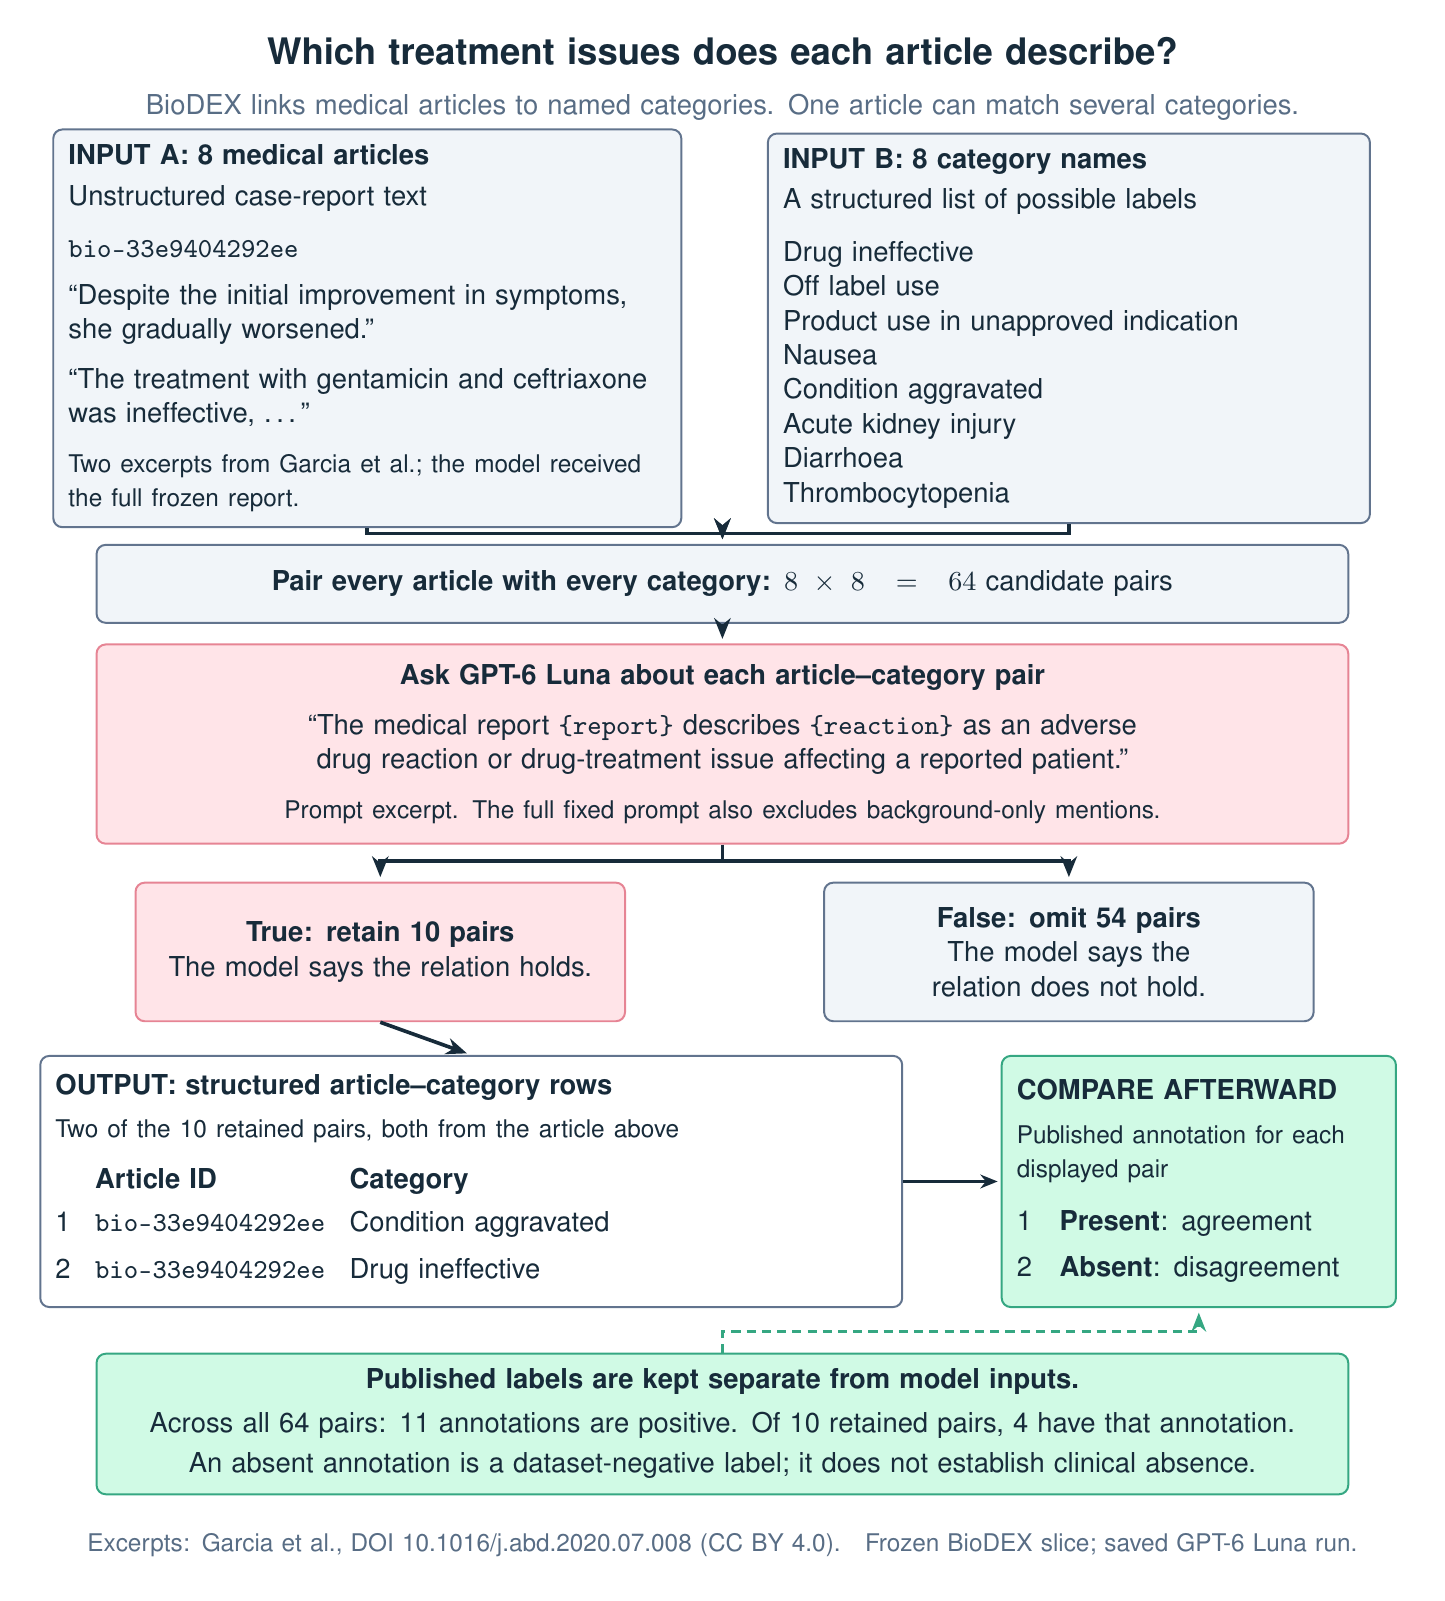

**Figure 1. From medical article text to an article–category relation.** The inputs and output rows come from the saved BioDEX experiment. Model predictions and published reaction annotations are shown separately. Article excerpts: [Garcia et al.](https://doi.org/10.1016/j.abd.2020.07.008), CC BY 4.0; dataset: [BioDEX](https://arxiv.org/abs/2305.13395). [Full-size PDF](record-linkage-tutorial/diagrams/12-biodex-workflow.pdf).

Literal BioDEX matching recovers **one of 11 annotated relations**, versus four for GPT-6 Luna and six for GPT-5.6 Luna. The models also accept six and seven unannotated pairs, respectively, versus four for the literal baseline. Annotation disagreement remains visible; it is not automatically a clinically adjudicated error.

One useful mechanism is the leishmaniasis report's description of treatment producing no response: GPT-5.6 Luna recognizes the annotated “Drug ineffective” relation despite different wording. Both models also accept “Acute kidney injury,” absent from that report's selected annotations, alongside patient-specific laboratory findings. Those acceptances retain their original annotation-based score. [Frozen decisions and source text](record-linkage-tutorial/data/unstructured/README.md).

On FEVER, GPT-6 Luna agrees with **12/12** labels and GPT-5.6 Luna with **11/12**, versus **6/12** for overlap. This illustrates interpretation after successful retrieval. The claims span nine subjects, exclude insufficient-evidence cases and may be familiar from training. No population accuracy or optimizer speedup follows from the example.

## 5. Tools and the next evidence

A separate native LOTUS agent demonstration reads three **invented** office returns, chooses revisions, normalizes units and computes **1,130/1,600 = 70.625%**. Its saved trace validates that one execution. The compact check below keeps it reproducible without printing the complete tool transcript. [Inputs](record-linkage-tutorial/data/agentic-office-returns.json) · [Saved execution](record-linkage-tutorial/results/agentic-office-returns-gpt-6-luna.json).

In [5]:
from agentic_demo import load_demo, run_live as run_agentic_live
agentic_path = run_agentic_live(budget_usd=0.10) if RUN_AGENTIC_LIVE else None
agentic_snapshot = load_demo(agentic_path)
v = agentic_snapshot['validation']
display(pd.DataFrame([{'Completed': v['completed_total'], 'Eligible': v['eligible_total'],
                      'Pooled completion (%)': v['pooled_completion_percent'],
                      'Model calls': v['model_calls'], 'Tool calls': v['tool_calls']}]))

,Completed,Eligible,Pooled completion (%),Model calls,Tool calls
0,1130,1600,70.625,12,7


The useful next question is where real document interpretation improves a resulting linked dataset after capable extraction and retrieval. Evaluate candidate misses, false links, unresolved cases and review effort alongside recovered links. Add an iterative agent only when it contributes beyond a one-shot decision with the same tools.

The [NSO results and to-dos](nso-semantic-workflows.ipynb) apply that test to the completed experiments. Detailed fitting, full disagreements, historical runs and research background remain in the [supporting evidence](record-linkage-tutorial/README.md) and [research notes](../research/error-guided-record-linkage/README.md).